### Подготовка данных

In [1]:
import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-robberies.csv"
time_series = pd.read_csv(url)

time_series.sample(5)

,Month,Robberies
51,1970-04,90
102,1974-07,355
49,1970-02,107
27,1968-04,84
13,1967-02,59


In [2]:
len(time_series)

118

In [3]:
time_series.isnull().sum()

,0
Month,0
Robberies,0


In [4]:
time_series.dtypes

,0
Month,object
Robberies,int64


In [5]:
time_series['Month'] = pd.to_datetime(time_series['Month'])
time_series.set_index('Month', inplace=True)

In [6]:
time_series.dtypes

,0
Robberies,int64


In [7]:
time_series.sample(5)

,Robberies
Month,
1971-06-01,155
1974-12-01,391
1972-09-01,308
1967-09-01,57
1967-10-01,52


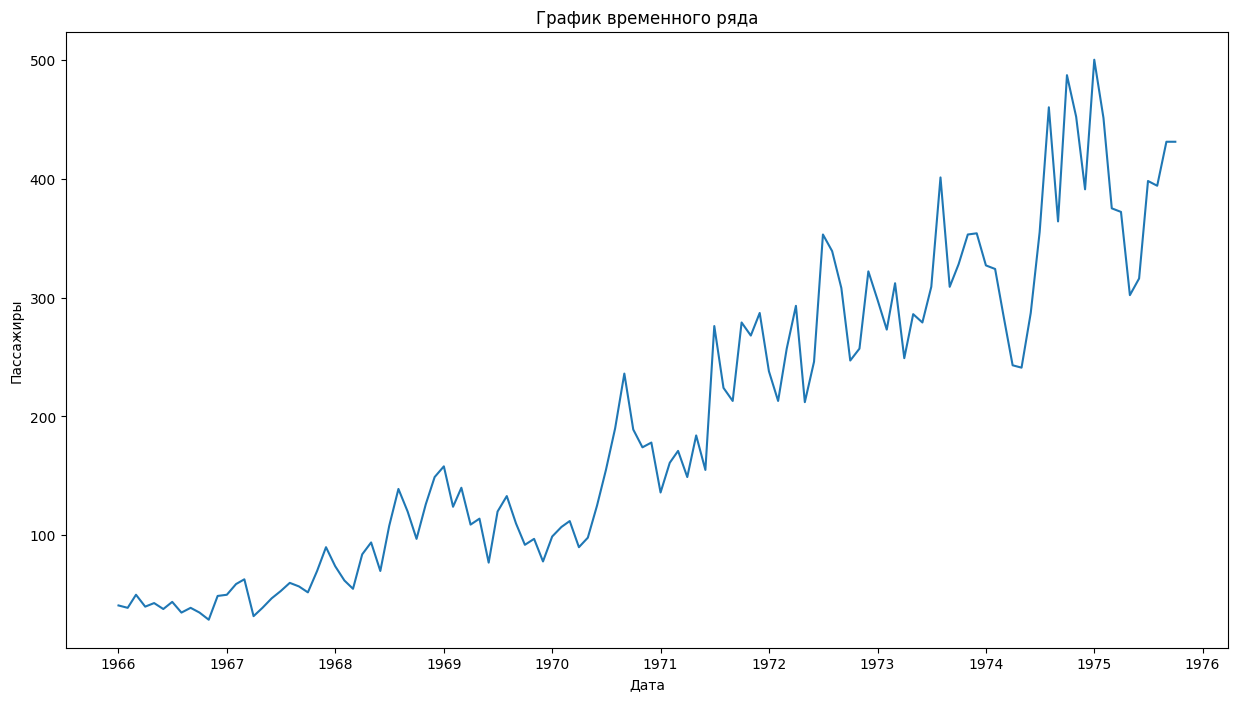

In [8]:
plt.figure(figsize=(15,8))
plt.plot(time_series['Robberies'])
plt.title('График временного ряда')
plt.xlabel('Дата')
plt.ylabel('Пассажиры')
plt.show()

In [9]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

In [10]:
train, test = train_test_split(time_series, test_size=0.2, shuffle=False)

In [11]:
train.shape

(94, 1)

In [12]:
test.shape

(24, 1)

In [13]:
test.head()

,Robberies
Month,
1973-11-01,353
1973-12-01,354
1974-01-01,327
1974-02-01,324
1974-03-01,285


### Поиск параметров

In [14]:
def search_optimal_sarimax(time_series, seasonal_cycle):
    # Взял максимальный интервал, которое мое устройство осилило
    order_vals = diff_vals = ma_vals = range(0, 3)
    pdq_combinations = list(itertools.product(order_vals, diff_vals, ma_vals))
    seasonal_combinations = [(combo[0], combo[1], combo[2], seasonal_cycle) for combo in pdq_combinations]

    smallest_aic = float("inf")
    optimal_order_param = optimal_seasonal_param = None

    for order_param in pdq_combinations:
        for seasonal_param in seasonal_combinations:
            try:
                sarimax_model = sm.tsa.statespace.SARIMAX(time_series,
                                                          order=order_param,
                                                          seasonal_order=seasonal_param,
                                                          enforce_stationarity=False,
                                                          enforce_invertibility=False)

                model_results = sarimax_model.fit()
                if model_results.aic < smallest_aic:
                    smallest_aic = model_results.aic
                    optimal_order_param = order_param
                    optimal_seasonal_param = seasonal_param
            except:
                print("Aaa")
                continue

    return optimal_order_param, optimal_seasonal_param, smallest_aic

seasonal_cycle_length = 12
#optimal_order_param, optimal_seasonal_param, smallest_aic = search_optimal_sarimax(time_series, seasonal_cycle_length)
optimal_order_param, optimal_seasonal_param, smallest_aic = (0, 2, 1), (1, 2, 2, 12), 10.0
print('SARIMAX{}x{} - AIC:{}'.format(optimal_order_param, optimal_seasonal_param, smallest_aic))

SARIMAX(0, 2, 1)x(1, 2, 2, 12) - AIC:10.0


### Обучение модели

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

order = optimal_order_param
seasonal_order = optimal_seasonal_param

model = SARIMAX(train, order=order, seasonal_order=seasonal_order)

In [16]:
fitted_model = model.fit()
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                               Robberies   No. Observations:                   94
Model:             SARIMAX(0, 2, 1)x(1, 2, [1, 2], 12)   Log Likelihood                -369.391
Date:                                 Mon, 04 May 2026   AIC                            748.782
Time:                                         07:13:33   BIC                            759.880
Sample:                                     01-01-1966   HQIC                           753.180
                                          - 10-01-1973                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9998     63.408     -0.016      0.987    -125.277     123.277
ar.S.L12      -0.0033      0.865     -0.004      0.997      -1.699       1.693
ma.S.L12      -1.8714     69.422     -0.027      0.978    -137.936     134.193
ma.S.L24       0.9894     71.172      0.014      0.989    -138.505     140.484
sigma2      1205.2143   8.12e+04      0.015      0.988   -1.58e+05     1.6e+05
===================================================================================
Ljung-Box (L1) (Q):                  12.03   Jarque-Bera (JB):                 1.11
Prob(Q):                              0.00   Prob(JB):                         0.57
Heteroskedasticity (H):               8.50   Skew:                            -0.06
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.61
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

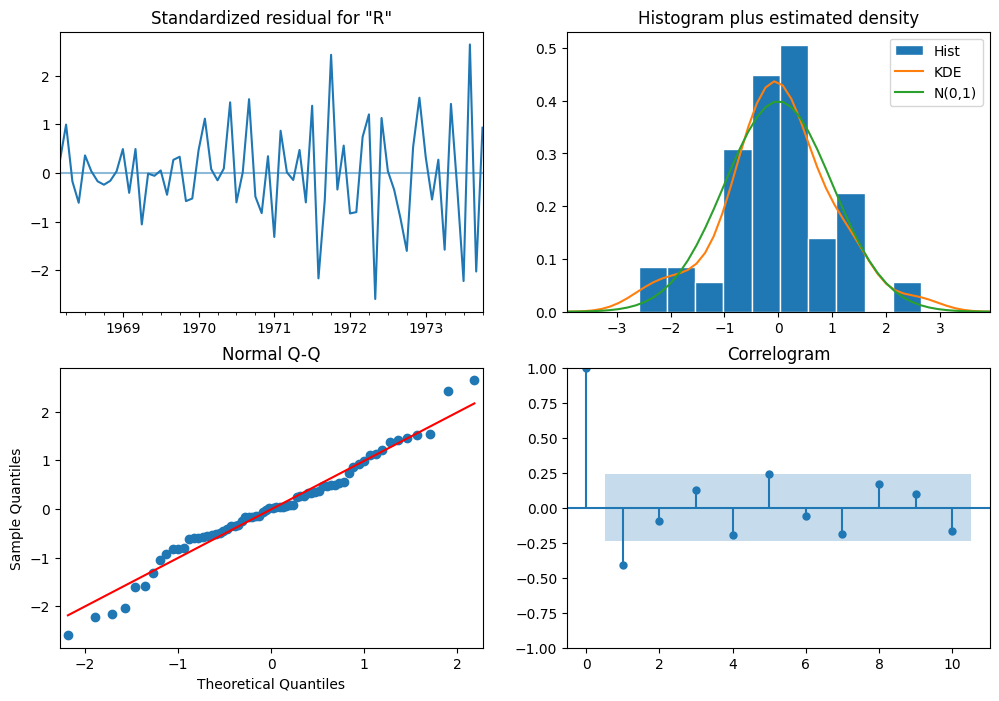

In [17]:
fitted_model.plot_diagnostics(figsize=(12, 8))
plt.show()

### Прогноз

In [18]:
pred = fitted_model.get_prediction(start=test.index[0], end=test.index[-1], dynamic=False)
forecast_values = pred.predicted_mean

In [19]:
actual_values = test
forecast_mse = ((forecast_values - actual_values) ** 2).mean()

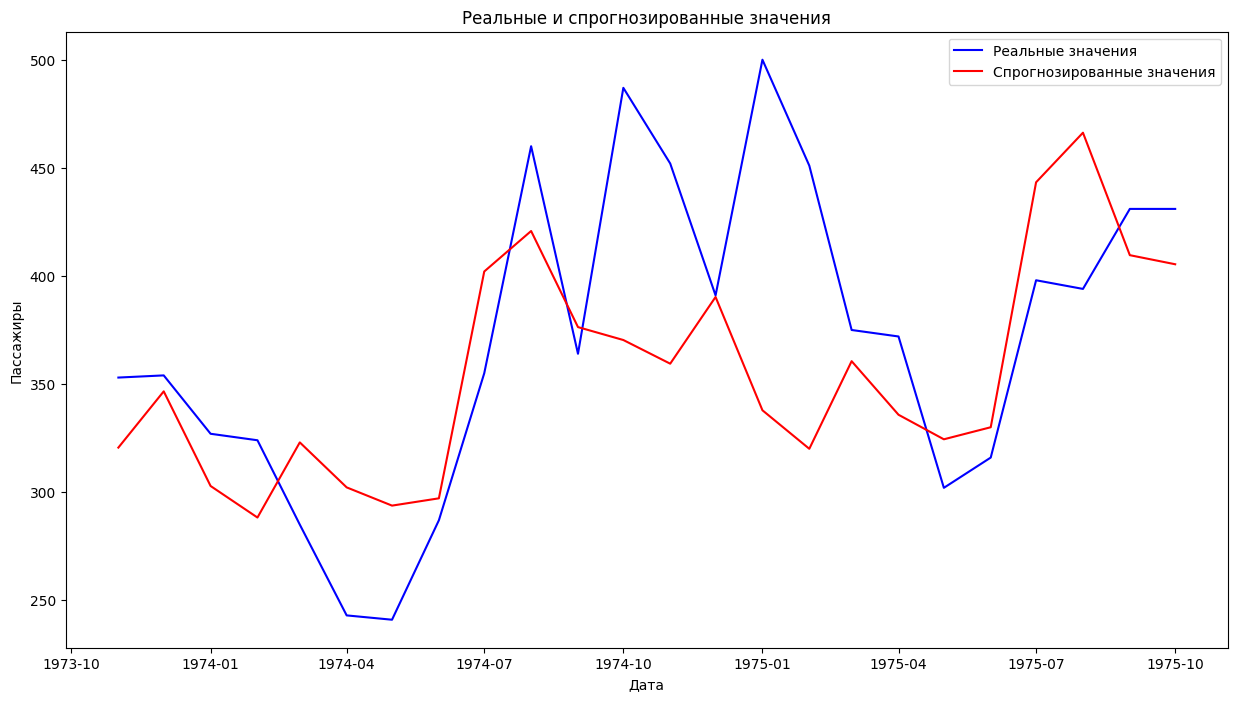

In [20]:
plt.figure(figsize=(15,8))

plt.plot(actual_values.index, actual_values, label='Реальные значения', color='blue')

plt.plot(forecast_values.index, forecast_values, label='Спрогнозированные значения', color='red')

plt.title('Реальные и cпрогнозированные значения')
plt.xlabel('Дата')
plt.ylabel('Пассажиры')
plt.legend()

plt.show()

### Реализации бутстрапа

In [21]:
def residual_bootstrap(fitted_model, steps, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = np.random.choice(residuals, size=steps, replace=True)
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [22]:
# max - половина максимальной ошибки
# mean - половина средней ошибки
# median - половина медианной ошибки
def naive_bootstraps(fitted_model, steps, method, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    abs_resids = np.abs(residuals)

    if method == 'max':
        error_magnitude = np.max(abs_resids) / 2.0
    elif method == 'mean':
        error_magnitude = np.mean(abs_resids) / 2.0
    elif method == 'median':
        error_magnitude = np.median(abs_resids) / 2.0
    else:
        raise ValueError("[naive] no such method ")

    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = error_magnitude
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [23]:
!pip install arch

import arch
from arch.bootstrap import MovingBlockBootstrap

def arch_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    point_forecast = fitted_model.forecast(steps=steps)

    mbb = MovingBlockBootstrap(block_length, residuals)
    forecasts = []

    for data in mbb.bootstrap(n_bootstrap):
        # data[0][0] содержит сгенерированный ряд остатков
        boot_resid = data[0][0]

        if len(boot_resid) >= steps:
            boot_forecast = point_forecast.values + boot_resid[:steps]
            forecasts.append(boot_forecast)
        else:
            # Если остатков не хватает, повторяем их циклически
            repeated_resid = np.tile(boot_resid, int(np.ceil(steps / len(boot_resid))))[:steps]
            boot_forecast = point_forecast.values + repeated_resid
            forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)

    return lower, upper, forecasts

In [24]:
!pip install tsbootstrap

from tsbootstrap import WholeSieveBootstrap

def sieve_bootstrap(fitted_model, steps, min_lag=1, max_lag=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid.values

    centered_resid = residuals - np.mean(residuals)

    sieve = WholeSieveBootstrap(n_bootstraps=n_bootstrap)

    boot_residuals = sieve.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [25]:
from tsbootstrap import MovingBlockBootstrap as tsbootstrap_mbb

def tsbootstrap_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid.values

    centered_resid = residuals - np.mean(residuals)

    mbb = tsbootstrap_mbb(n_bootstraps=n_bootstrap, rng=random_state, block_length=block_length)

    boot_residuals = mbb.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

### Сравнение методов

In [26]:
def evaluate(true_values, lower, upper):
    true_vals = np.array(true_values).flatten()

    # доля истинных значений, попавших в интервал
    coverage = np.mean((lower <= true_vals[:len(lower)]) & (true_vals[:len(lower)] <= upper))

    # средняя ширина интервала
    avg_width = np.mean(upper - lower)
    return coverage, avg_width

forecast_steps = 24
forecast = fitted_model.forecast(steps=forecast_steps)

test_values = test.values.flatten()[:forecast_steps]

results = {}

# SARIMA
try:
    prediction = fitted_model.get_forecast(forecast_steps)
    arima_forecast = prediction.predicted_mean
    arima_ci = prediction.conf_int(alpha=0.05)
    lower_arima = arima_ci.iloc[:, 0]
    upper_arima = arima_ci.iloc[:, 1]
    coverage_arima, width_arima = evaluate(test_values, lower_arima, upper_arima)
    results['SARIMA'] = {'coverage': coverage_arima, 'width': width_arima, 'lower': lower_arima, 'upper': upper_arima}
    print("SARIMA - OK")
except Exception as e:
    print(f"SArima error: {e}")

# Residual Bootstrap
try:
    lower_res_c, upper_res_c, all_forecasts_res_c  = residual_bootstrap(fitted_model, forecast_steps)
    coverage_res_c, width_res_c = evaluate(test_values, lower_res_c, upper_res_c)
    results['Residual Bootstrap Correct'] = {'coverage': coverage_res_c, 'width': width_res_c, 'lower': lower_res_c, 'upper': upper_res_c}
    print("Residual Bootstrap Correct - OK")
except Exception as e:
    print(f"Residual Bootstrap Correct error: {e}")

# Naive
try:
    for method in ["max", "mean", "median"]:
        lower_naive, upper_naive, all_forecasts_naive  = naive_bootstraps(fitted_model, forecast_steps, method)
        coverage_naive, width_naive = evaluate(test_values, lower_naive, upper_naive)
        results['Naive-' + method] = {'coverage': coverage_naive, 'width': width_naive, 'lower': lower_naive, 'upper': upper_naive}
        print(f" ### Naive {method} - OK")
    print("Naive - OK")
except Exception as e:
    print(f"Naive: {e}")

# ARCH block Bootstrap
try:
    lower_arch, upper_arch, _ = arch_block_bootstrap(fitted_model, forecast_steps, block_length=12)
    coverage_arch, width_arch = evaluate(test_values, lower_arch, upper_arch)
    results['ARCH Block Bootstrap'] = {'coverage': coverage_arch, 'width': width_arch, 'lower': lower_arch, 'upper': upper_arch}
    print("ARCH Block Bootstrap - OK")
except Exception as e:
    print(f"ARCH Block Bootstrap error: {e}")

# Sieve bootstrap
try:
    lower_sieve, upper_sieve, _ = sieve_bootstrap(fitted_model, forecast_steps)
    coverage_sieve, width_sieve = evaluate(test_values, lower_sieve, upper_sieve)
    results['Sieve Bootstrap'] = {'coverage': coverage_sieve, 'width': width_sieve, 'lower': lower_sieve, 'upper': upper_sieve}
    print("Sieve Bootstrap - OK")
except Exception as e:
    print(f"Sieve Bootstrap error: {e}")

# tsbootstrap block bootstrap
try:
    lower_block, upper_block, _ = tsbootstrap_block_bootstrap(fitted_model, forecast_steps)
    coverage_block, width_block = evaluate(test_values, lower_block, upper_block)
    results['Tsbootstrap Block Bootstrap'] = {'coverage': coverage_block, 'width': width_block, 'lower': lower_block, 'upper': upper_block}
    print("Tsbootstrap Block Bootstrap - OK")
except Exception as e:
    print(f"Tsbootstrap Block Bootstrap error: {e}")

results_df = pd.DataFrame(results).T[['coverage', 'width']]
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*50)
print(results_df)

SARIMA - OK
Residual Bootstrap Correct - OK
 ### Naive max - OK
 ### Naive mean - OK
 ### Naive median - OK
Naive - OK
ARCH Block Bootstrap - OK
[  41.07615366  -32.63995722   12.99753333  -20.8812654    13.00709066
   -7.88123378   11.04993091  -14.8876834    13.02684188   -7.8811687
   -1.95006887   26.03677526  -40.88027896   30.7079105   -24.31636863
   -3.64556411   18.58084455   13.19035985  -18.29967106   23.40751169
  -29.22126296    9.84211456   26.13582287  -36.67684983   -7.81247739
  -14.58918353   27.13031613   98.71129     -16.04596168  -55.44929244
   32.20655355    3.27967807  -14.8033741   -20.67248486  -13.72175095
    2.91782498   41.47779221  -29.05942625   33.66801595  -69.98940147
   -0.71360659   -3.63915083    3.40425042  -28.2231728    17.00879158
   20.94370045  -35.95422081  -32.43544357   29.13891708   62.9789296
    4.46653051   -8.19394372    5.01810705   78.330695    -32.24996898
    0.81317207   80.6694831   -25.55646133  -43.50157474   18.23198343
  -69

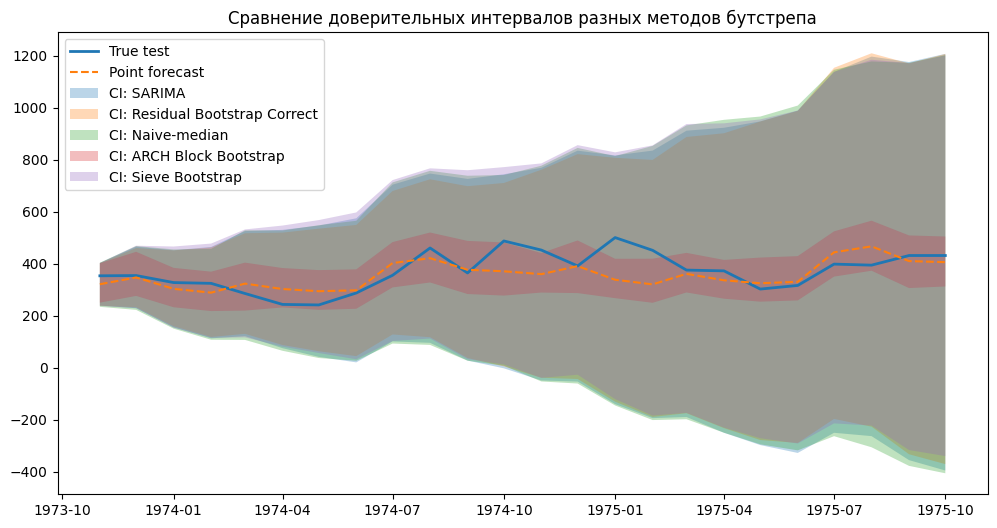

In [27]:
plt.figure(figsize=(12,6))
plt.plot(test.index[:forecast_steps], test_values, label='True test', linewidth=2)
plt.plot(test.index[:forecast_steps], forecast[:forecast_steps], label='Point forecast', linestyle='--')

to_plot = ['SARIMA', 'Residual Bootstrap Correct', 'Naive-median', 'ARCH Block Bootstrap', 'Sieve Bootstrap']

for name in results.keys():
    if name not in to_plot:
        continue

    lower = results[name]['lower']
    upper = results[name]['upper']

    plt.fill_between(test.index[:forecast_steps], lower, upper, alpha=0.3, label=f'CI: {name}')

plt.legend()
plt.title('Сравнение доверительных интервалов разных методов бутстрепа')
plt.show()